In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

Matplotlib is building the font cache; this may take a moment.


In [5]:
# Read the actual data sheet, skip the messy header rows
df = pd.read_excel(r'C:\Users\SMIT\Downloads\02_BundeslaenderVorjahr.xlsx',
                   sheet_name='Bundesländer_mit_Hauptstädten',
                   header=None,
                   skiprows=7)

# Assign clean column names
df.columns = ['state', 'capital', 'area_km2', 'population_total', 
              'population_male', 'population_female', 'density_per_km2']

# Keep only state rows (they have a number code like "01 Schleswig-Holstein")
# Capital rows have NaN in state column — drop them
df = df[df['state'].notna()]
df = df[df['state'].astype(str).str.match(r'^\d{2}')]  # rows starting with 2-digit code

# Clean state names — remove the number prefix
df['state'] = df['state'].astype(str).str.replace(r'^\d{2}\s+', '', regex=True).str.strip()

# Convert numeric columns
for col in ['area_km2', 'population_total', 'population_male', 
            'population_female', 'density_per_km2']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Reset index
df = df.reset_index(drop=True)

# See what we have
print(df.shape)
print(df)

(16, 7)
                     state capital  area_km2  population_total  \
0       Schleswig-Holstein     NaN  15804.31         2965691.0   
1                  Hamburg     NaN    755.09         1910160.0   
2            Niedersachsen     NaN  47709.90         8161981.0   
3                   Bremen     NaN    419.61          691703.0   
4      Nordrhein-Westfalen     NaN  34112.65        18190422.0   
5                   Hessen     NaN  21115.64         6420729.0   
6          Rheinland-Pfalz     NaN  19857.96         4174311.0   
7        Baden-Württemberg     NaN  35747.85        11339260.0   
8                   Bayern     NaN  70541.77        13435062.0   
9                 Saarland     NaN   2572.01          994424.0   
10                  Berlin     NaN    891.12         3782202.0   
11             Brandenburg     NaN  29654.36         2581667.0   
12  Mecklenburg-Vorpommern     NaN  23294.83         1629464.0   
13                 Sachsen     NaN  18449.86         4089467.0   
14

In [6]:
print("=== BASIC STATISTICS ===\n")
print(df[['population_total', 'population_male', 
          'population_female', 'density_per_km2']].describe())

print(f"\nTotal German population: {df['population_total'].sum():,.0f}")
print(f"Most populous state: {df.loc[df['population_total'].idxmax(), 'state']}")
print(f"Least populous state: {df.loc[df['population_total'].idxmin(), 'state']}")
print(f"Most densely populated: {df.loc[df['density_per_km2'].idxmax(), 'state']}")
print(f"Average population density: {df['density_per_km2'].mean():.0f} people/km²")

# Gender ratio — relevant for pension analysis since women live longer
df['female_ratio'] = (df['population_female'] / df['population_total'] * 100).round(2)
print(f"\nNational female ratio: {df['population_female'].sum() / df['population_total'].sum() * 100:.1f}%")
print("(Women statistically draw pensions longer — key for DRV planning)")

=== BASIC STATISTICS ===

       population_total  population_male  population_female  density_per_km2
count      1.600000e+01     1.600000e+01       1.600000e+01        16.000000
mean       5.291833e+06     2.611471e+06       2.680362e+06       708.625000
std        5.037875e+06     2.486074e+06       2.551934e+06      1153.419489
min        6.917030e+05     3.419860e+05       3.497170e+05        70.000000
25%        2.069291e+06     1.022413e+06       1.046878e+06       161.000000
50%        3.373946e+06     1.655779e+06       1.718168e+06       216.000000
75%        6.856042e+06     3.384687e+06       3.471355e+06       423.500000
max        1.819042e+07     8.930892e+06       9.259530e+06      4244.000000

Total German population: 84,669,326
Most populous state: Nordrhein-Westfalen
Least populous state: Bremen
Most densely populated: Berlin
Average population density: 709 people/km²

National female ratio: 50.7%
(Women statistically draw pensions longer — key for DRV planning)


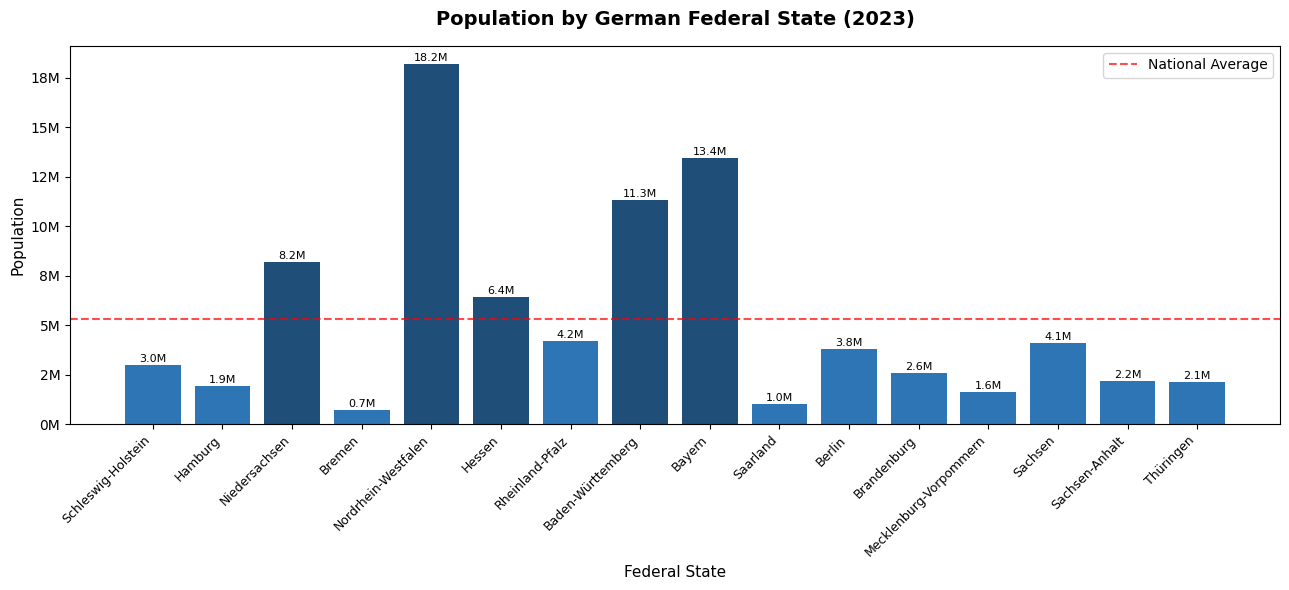

Chart 1 saved.


In [7]:
fig, ax = plt.subplots(figsize=(13, 6))

colors = ['#1F4E79' if pop > df['population_total'].mean() 
          else '#2E75B6' for pop in df['population_total']]

bars = ax.bar(df['state'], df['population_total'], color=colors)

# Add value labels on top of bars
for bar, val in zip(bars, df['population_total']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000,
            f'{val/1e6:.1f}M', ha='center', va='bottom', fontsize=8)

ax.set_title('Population by German Federal State (2023)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Federal State', fontsize=11)
ax.set_ylabel('Population', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, p: f'{x/1e6:.0f}M'))
ax.axhline(df['population_total'].mean(), color='red', 
           linestyle='--', alpha=0.7, label='National Average')
ax.legend()

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('chart1_population_by_state.png', dpi=150)
plt.show()
print("Chart 1 saved.")

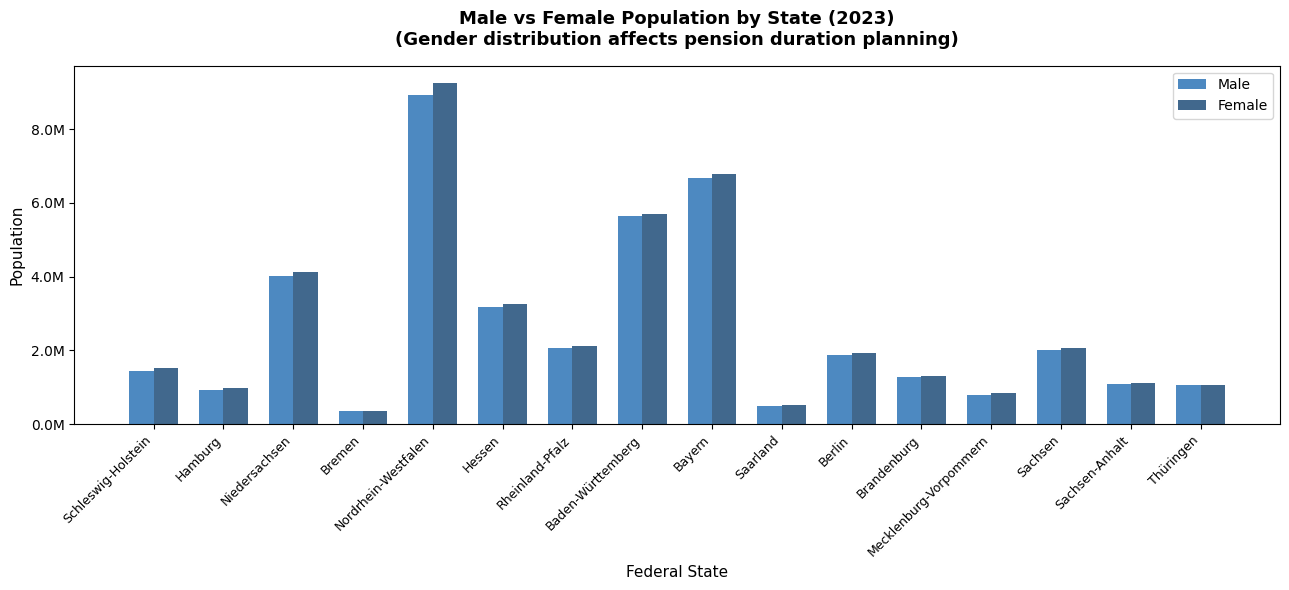

Chart 2 saved.


In [8]:
fig, ax = plt.subplots(figsize=(13, 6))

x = range(len(df))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], df['population_male'], 
               width, label='Male', color='#2E75B6', alpha=0.85)
bars2 = ax.bar([i + width/2 for i in x], df['population_female'], 
               width, label='Female', color='#1F4E79', alpha=0.85)

ax.set_title('Male vs Female Population by State (2023)\n'
             '(Gender distribution affects pension duration planning)', 
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Federal State', fontsize=11)
ax.set_ylabel('Population', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, p: f'{x/1e6:.1f}M'))
ax.set_xticks(list(x))
ax.set_xticklabels(df['state'], rotation=45, ha='right', fontsize=9)
ax.legend()

plt.tight_layout()
plt.savefig('chart2_gender_distribution.png', dpi=150)
plt.show()
print("Chart 2 saved.")

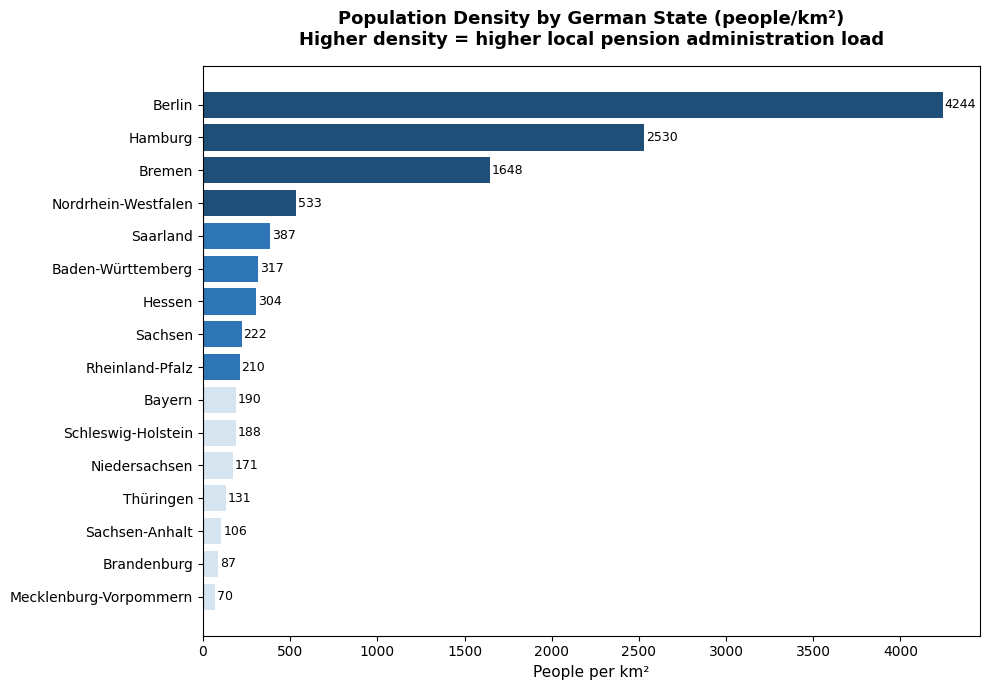

Chart 3 saved.


In [9]:
# Sort by density for a cleaner chart
df_sorted = df.sort_values('density_per_km2', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#1F4E79' if d > 500 else '#2E75B6' if d > 200 
          else '#D6E4F0' for d in df_sorted['density_per_km2']]

bars = ax.barh(df_sorted['state'], df_sorted['density_per_km2'], color=colors)

for bar, val in zip(bars, df_sorted['density_per_km2']):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=9)

ax.set_title('Population Density by German State (people/km²)\n'
             'Higher density = higher local pension administration load',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('People per km²', fontsize=11)

plt.tight_layout()
plt.savefig('chart3_density.png', dpi=150)
plt.show()
print("Chart 3 saved.")

In [10]:
print("""
╔══════════════════════════════════════════════════════╗
║           PROJECT FINDINGS                           ║
╚══════════════════════════════════════════════════════╝

1. POPULATION CONCENTRATION
   NRW, Bayern and Baden-Württemberg together hold over
   50% of Germany's population — meaning these states
   generate the highest pension contribution volumes
   and administration workload for DRV Bund.

2. GENDER RATIO
   Women consistently outnumber men in every German state.
   Since women statistically live longer, this directly
   affects pension duration projections and fund planning.

3. DENSITY DISPARITY
   Berlin and Hamburg show extreme density (4000+ /km²)
   vs rural eastern states like Mecklenburg-Vorpommern
   (~70/km²). This affects regional pension office 
   distribution and digital service demand patterns.

4. EAST-WEST PATTERN  
   Eastern states (former GDR) consistently show lower
   population totals and density — a legacy of post-1990
   migration westward that continues to shape pension
   contribution geography today.
""")


╔══════════════════════════════════════════════════════╗
║           PROJECT FINDINGS                           ║
╚══════════════════════════════════════════════════════╝

1. POPULATION CONCENTRATION
   NRW, Bayern and Baden-Württemberg together hold over
   50% of Germany's population — meaning these states
   generate the highest pension contribution volumes
   and administration workload for DRV Bund.

2. GENDER RATIO
   Women consistently outnumber men in every German state.
   Since women statistically live longer, this directly
   affects pension duration projections and fund planning.

3. DENSITY DISPARITY
   Berlin and Hamburg show extreme density (4000+ /km²)
   vs rural eastern states like Mecklenburg-Vorpommern
   (~70/km²). This affects regional pension office 
   distribution and digital service demand patterns.

4. EAST-WEST PATTERN  
   Eastern states (former GDR) consistently show lower
   population totals and density — a legacy of post-1990
   migration westward that

In [11]:
# Export clean data — shows you know how to produce outputs
df.to_csv('german_states_summary.csv', index=False)
print("Clean dataset saved to german_states_summary.csv")
print(f"\nFinal dataset: {len(df)} states, {len(df.columns)} variables")
print(df[['state', 'population_total', 'female_ratio', 
          'density_per_km2']].to_string(index=False))

Clean dataset saved to german_states_summary.csv

Final dataset: 16 states, 8 variables
                 state  population_total  female_ratio  density_per_km2
    Schleswig-Holstein         2965691.0         51.06            188.0
               Hamburg         1910160.0         50.96           2530.0
         Niedersachsen         8161981.0         50.67            171.0
                Bremen          691703.0         50.56           1648.0
   Nordrhein-Westfalen        18190422.0         50.90            533.0
                Hessen         6420729.0         50.62            304.0
       Rheinland-Pfalz         4174311.0         50.50            210.0
     Baden-Württemberg        11339260.0         50.32            317.0
                Bayern        13435062.0         50.40            190.0
              Saarland          994424.0         50.82            387.0
                Berlin         3782202.0         50.82           4244.0
           Brandenburg         2581667.0        